In [41]:
import numpy as np
import pandas as pd
from scipy.stats import binom
import matplotlib.pyplot as plt

np.random.seed(1492)

# Bootstrap Estimation
#### Recap from the previous lectures

## Motivation:

Imagine this situation: You have been tasked with carrying out a statistical analysis of a population. You have several variables, and the dataset you are working with is relativelly small. You therefore conclude that, given the size of the dataset, it is difficult to say whether this data is representative of the entire population. **This is where bootstrap sampling can be useful.**

Bootstrap sampling is a statistical technique for estimating measures of a population when the underlying distribution is unknown and you have a small dataset. This technique allows us to estimate statistical quantities such as the mean, median, standard deviation or any other statistic of interest directly from the observed data, and provides us with a confidence interval for each of them without it necessarily being limited to the sample we have.

## How?

This technique works in a very simple way. Let’s assume we have a variable of interest called X with a size of 100. The bootstrap method would do the following:

- From the initial observed values, we generate many (let's say 1000) different samples of the same size (size 100) **with replacement**. This aspect of replacement is important

- For each of the resamples generated, we will now calculate the statistical of interest, for example, we calculate the *mean* of each of the 1000 resamples.

- Now we have 1000 estimations of the mean, so we can use it to create confidence intervals

Sampling with replacement allows us to, at each iteration, have a different approximation of the global distribution. If we sample without replacement we would create the same sample many times but with different orders.

## Exercise 1

To make it easy, let's see an easy example!

To make it visual, we will start with a sample where we **know** the underlying distribution. We will start sampling from a binomial distribution with parameters $n=16$ and $p=0.75$

#### a)
Given that $\mu=np$ and $\sigma^2=np(1-p)$.

Calculate the mean ($\mu$) and the variance ($\sigma^2$) our sample will *theorically* have.

In [42]:
n = 16
p = 0.75
mu = n*p
sigma2 = n*p*(1-p)
print(f"Mean (mu): {mu}")
print(f"Variance (sigma^2): {sigma2}")

Mean (mu): 12.0
Variance (sigma^2): 3.0


### b)
Now that we know the *"theorical values"* of the mean and variance, let's simulate 100000 values of a distribution like it and calculate the mean and variance of this sample.

$\color{red}{\text{Use the function }\texttt{binom}\text{ from }\texttt{scipy.stats}\text{ to create the sample.}}$

In [43]:
import numpy as np
from scipy.stats import binom
np.random.seed(1492)

# Theoretical distribution
dist = binom(n, p)
# Big sample
big_sample = dist.rvs(size=100000)

print(f"--- Theoretical Parameters ---")
print(f"Expected Mean: {dist.mean():.2f}")
print(f"Expected Variance: {dist.var():.2f}")

print(f"\n--- Sample Results ---")
print(f"Obtained Mean: {np.mean(big_sample):.2f}")
print(f"Obtained Variance: {np.var(big_sample):.2f}")

--- Theoretical Parameters ---
Expected Mean: 12.00
Expected Variance: 3.00

--- Sample Results ---
Obtained Mean: 11.99
Obtained Variance: 3.03


### c)
Of course, with a huge sample you might have gotten if not exactly the expected mean and variance, it must be very close to it.

Now do the same but instead of sampling 100000 values, create a sample of only 20 values with the same distribution, print it and calculate the mean and the variance.

In [44]:
import numpy as np
from scipy.stats import binom
np.random.seed(1492)

dist_small = binom(n, p)
small_sample = dist_small.rvs(size=20)

print("Sample:")
print(small_sample)

print(f"Mean: {np.mean(small_sample):.2f}")
print(f"Variance: {np.var(small_sample):.2f}")

Sample:
[13 10 14 14 13 13  9 11 11 12 13 13  9 12 12 15 11 12 12 12]
Mean: 12.05
Variance: 2.35


### d)
You might have gotten not exactly the expected values of the mean and variance but slightly different ones. Why do this happen? Simply because the sample we just generated is small and not representative enough for the global population.

So now we will apply bootstrap to fix this issue. You have to create 10000 populations resampling from the original sample you just created before, with replacement, and the same size as before, i.e. 20; and for each of the population you have to calculate the mean and the variance. At the end you must finish with 2 list of 10000 values of mean and variance.

$\color{red}{\text{Use the function }\texttt{np.random.choice}\text{ and remember to set }\texttt{replace=True}}$

In [ ]:
import numpy as np
np.random.seed(1492)

n_iter = 100000
mean_boot = []
var_boot = []

for _ in range(n_iter):
    temporal_sample = np.random.choice(small_sample, size=len(small_sample), replace=True)
    mean_boot.append(np.mean(temporal_sample))
    var_boot.append(np.var(temporal_sample))

### e)
Now, with the 2 lists, calculate the $95\%$ confidence interval for both the mean and the variance and show them.

$\color{red}{\text{You can use the function }\texttt{np.percentile}}$

In [46]:
import numpy as np
conf_int_mean = np.percentile(mean_boot, [2.5, 97.5])
conf_int_var = np.percentile(var_boot, [2.5, 97.5])

print("Mean Bootstrap Confidence Interval (95%):", conf_int_mean)
print("Variance Bootstrap Confidence Interval (95%):", conf_int_var)

Mean Bootstrap Confidence Interval (95%): [11.35 12.7 ]
Variance Bootstrap Confidence Interval (95%): [1.01   3.6475]


The real value of the mean and the variance should be inside these confidence intervals. Now you checked how this method can be used to, instead of giving a one unique value for a statistic, create a confidence interval that will be ensure you to have better estimations. 

### f)
Until now we have use what is called **Non-parametric bootstrap**. It means that we are not assuming any known distribution.

However, in this example we can definitely assume that the samples we are working with are binomial distribution, so we can make use of this information to use what is called **Parametric bootstrap**. This parametric bootstrap is very useful when you can guess the kind of underlying distribution that generates the data.

To do an example of parametric bootstrap, we start by doing a point estimate of our parameter $n$ and $p$. We can start by setting the real value of $n$ that we know is $\hat{n}=16$, and for $p$ we can estimate it as $\hat{p}=\frac{\bar{X}}{\hat{n}}$.

Now that we have empirical estimations of our parameters and we know the samples follow a binomial distribution, what we will do is, instead of sampling from the original sample with replacement we will simulate many binomial samples with the estimated paramenters. And with all this simulations we can calculate our statistics of interest, in this case will be mean and variance.

Then, for the next exercise:

- Start by calculating $\hat{p}=\frac{\bar{X}}{\hat{n}}$.

- Then for $B=100000$ iterations:
  
  - Generate a binomial sample with the same size as the one we have, in our case, size $20$.

  - Calculate the mean and the variance of this new sample and add them into different lists.

- And now that you have 2 lists, one for means and another for variances, we can do the $95\%$ confidence interval for both statistics.

Follow these steps!

In [47]:
import numpy as np
from scipy.stats import binom
np.random.seed(1492)

p_hat = np.mean(small_sample) / n
num_replicas = 100000

simulation_param_mean = []
simulation_param_vari = []

for _ in range(num_replicas):
    simulation_param_mean.append(np.mean(binom.rvs(n, p_hat, size=(len(small_sample)))))
    simulation_param_vari.append(np.var(binom.rvs(n, p_hat, size=(len(small_sample)))))

print("Mean Bootstrap Confidence Interval (95%):", np.percentile(simulation_param_mean, [2.5, 97.5]))
print("Variance Bootstrap Confidence Interval (95%):", np.percentile(simulation_param_vari, [2.5, 97.5]))

Mean Bootstrap Confidence Interval (95%): [11.3 12.8]
Variance Bootstrap Confidence Interval (95%): [1.34 4.86]


### g)
In this section, we will apply one of the most effective tools derived from the bootstrap procedure. This mechanism allows us to estimate **the parameters of the underlying distribution** we are attempting to model. In our specific case, with a Binomial distribution, it enables us to estimate parameters $n$ and $p$.

In the previous section, we provided a point estimate for the parameter $\hat{p}$. Now, we will construct a confidence interval. To generate the different bootstrap samples, we simply need to draw samples from the original distribution with replacement and calculate $\frac{\bar{X}}{\hat{n}}$ to estimate $\hat{p}$ for each one. Similarly, to provide an estimation for $n$, we will calculate the **maximum** value of each resample. Apply non-parametric bootstrap to create confidence intervals for both parameters.

In [ ]:
import numpy as np
np.random.seed(1492)

n_boot = 10000
boot_p = []
boot_n = []

for _ in range(n_boot):

    resample = np.random.choice(small_sample, size=len(small_sample), replace=True)
    p_est = np.mean(resample) / n
    n_est = max(resample)
    boot_p.append(p_est)
    boot_n.append(n_est)

ci_p = np.percentile(boot_p, [2.5, 97.5])
ci_n = np.percentile(boot_n, [2.5, 97.5])

print("95% CI for p:", ci_p)
print("95% CI for n:", ci_n)

95% CI para p: [0.709375 0.79375 ]
95% CI para n: [13. 15.]


### h)

Finally, we will use an alternative method to calculate the confidence interval for $p$. This approach is based on the fact that, for a sufficiently large sample, the estimator $\hat{p}$ can be approximated by a Normal distribution centered at $p$ with a specific variance:

$$\hat{p} \sim N\left(p, \frac{p(1-p)}{n}\right)$$

As you may recall from your notes, we can standardize $\hat{p}$ by subtracting the mean and dividing by the standard deviation:

$$Z = \frac{\hat{p} - p}{\sqrt{\frac{p(1-p)}{n}}}$$

By doing this, the data in our sample begins to behave like a Standard Normal distribution, $Z \sim N(0, 1)$. Using this property, we can calculate the confidence interval based on the Normal distribution. We start from the following probability statement:

$$P\left( -z_{\alpha/2} \leq \frac{\hat{p} - p}{\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}} \leq z_{\alpha/2} \right) \approx 1 - \alpha$$

By isolating the parameter of interest ($p$), we obtain the formula for the confidence interval:

$$\hat{p} \pm z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

**Procedure to Estimate $p$ Using the Normal Distribution**

To calculate the $95\%$ confidence interval using this analytical method, follow these steps:
- 1. Calculate the point estimate: Find the sample mean ($\hat{p}$) and the estimated standard error $SE = \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$.
- 2. Determine the critical values: Find the 0.025 and 0.975 quantiles of a Standard Normal distribution $N(0, 1)$. (For a 95% confidence level, this value is approximately 1.96).

- 3. Compute the boundaries: Take the mean ($\hat{p}$) and add/subtract the standard error multiplied by the calculated quantile.

This process generates a confidence interval that provides a 95% probability that the true parameter we are estimating lies within these bounds.

Follow this process and show the point estimate of $\hat{p}$, $SE$, and the confidence interval generated by this procedure. Do you find different values than with the previous method?

In [49]:
import numpy as np
from scipy.stats import norm

# Point estimate
p_hat = np.mean(small_sample) / n
se = np.sqrt(p_hat * (1 - p_hat) / n)

# Critical values
z_lower = norm.ppf(0.025)
z_upper = norm.ppf(0.975)

# Confidence interval
ci_lower = p_hat + z_lower * se
ci_upper = p_hat + z_upper * se

print(f"Point estimate of p: {p_hat:.4f}")
print(f"Standard error: {se:.4f}")
print(f"95% Confidence Interval for p: ({ci_lower:.4f}, {ci_upper:.4f})")

Point estimate of p: 0.7531
Standard error: 0.1078
95% Confidence Interval for p: (0.5418, 0.9644)


## Exercise 2

To complete this exercise, we are going to use the **Gamma Distribution**.

This distribution has this characteristic: its domain (the set of possible values) consists only of positive real numbers.This makes it different from other distributions you might know:
- Normal Distribution: Its domain includes all real numbers (both positive and negative).
- Binomial Distribution: Its domain is limited to natural numbers (0, 1, 2...) within a specific interval.

For the Gamma distribution, the possible values range from zero to infinity $[0, \infty)$. This is why it is useful in real-world practice, as we often encounter continuous variables that can never be negative (like the time you wait for a bus or the amount of rainfall in a city).

This distribution is defined by two main parameters:
- Shape ($k$): Also frequently called alpha ($\alpha$).
- Scale ($\theta$): Also frequently called beta ($\beta$).

To calculate the theoretical mean and variance of this distribution based on its parameters, we use the following formulas:
$$E[X] = k \cdot \theta$$

$$Var(X) = k \cdot \theta ^2 $$

### a)
Let's start with a very simple exercise. Given the following parameters: $k = 2$, $\theta = 20$. Calculate the theoretical mean and the theoretical variance. One you have calculated them, plot the density function of this distribution between $-20$ and $200$. What is the value of this function for negative numbers?

$\color{red}{\text{You can use the function }\texttt{scipy.stats.gamma.pdf}}$

$$
\mu=k\times \theta\\
\mu = 2\times 20=40\\

\sigma^2=k\times \theta^2\\
\sigma^2=2\times 20^2=800 
$$
<span style="color:red">High variance!!!</span>

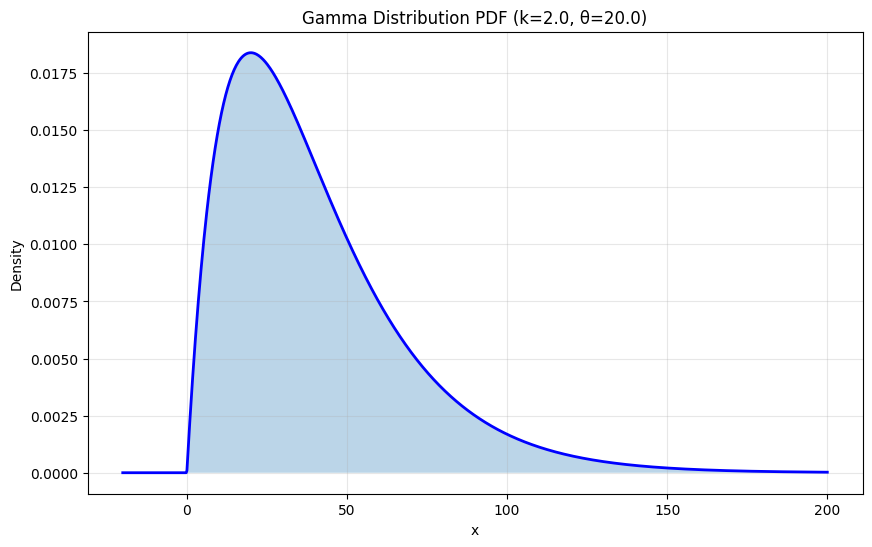

In [50]:
import numpy as np
from scipy.stats import gamma
import matplotlib.pyplot as plt

shape = 2.0
scale = 20.0
x = np.linspace(-20, 200, 1000)
pdf = gamma.pdf(x, a=shape, scale=scale)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, 'b-', linewidth=2)
plt.fill_between(x, pdf, alpha=0.3)
plt.xlabel('x')
plt.ylabel('Density')
plt.title(f'Gamma Distribution PDF (k={shape}, θ={scale})')
plt.grid(True, alpha=0.3)
plt.show()

### b)

Now we will use again simulated data, and this time we will visualize how the true mean deviates from the obtained with a small sample, but how with the confidence interval we alleviate this difference.

- 1. Generate a gamma sample with the parameters set above and size 50. $\color{red}{\text{You can use }\texttt{np.random.gamma}}$

- 2. Calculate mean and variance of this sample

- 3. Generate bootstrap samples of this populations to calculate the mean and the variance the same way as with the previous exercises.

- 4. Show the $95\%$ oercentiles of these approximations. Are the true values inside these intervals?

In [51]:
import numpy as np
np.random.seed(1789)

# 1) Gamma sample
shape = 2.0
scale = 20.0
gamma_s = np.random.gamma(shape, scale, size=50)

# 2) Statistics from the sample
mean_gamma = np.mean(gamma_s)
var_gamma = np.var(gamma_s)

print("Mean:", mean_gamma)
print("Std: ", var_gamma)

# 3) Bootstrap mean variance
n_boot = 10000
boot_means = []
boot_vars = []

for _ in range(n_boot):
    resample = np.random.choice(gamma_s, size=len(gamma_s), replace=True)
    boot_means.append(np.mean(resample))
    boot_vars.append(np.var(resample, ddof=1))

# 4) Confidence intervals
ci_mean = np.percentile(boot_means, [2.5, 97.5])
ci_std = np.percentile(boot_vars, [2.5, 97.5])

print("CI 95% mean:", ci_mean)
print("CI 95% std: ", ci_std)

Mean: 35.73823031028831
Std:  776.2302949376073
CI 95% mean: [28.56631011 44.08408198]
CI 95% std:  [ 378.70656292 1296.30521524]


### c)
Now create two histograms with the values of the mean and variance obtained during the bootstrap iterations. And add a vertical line of the theoretical value and another one with the value obtained with the small generated.   

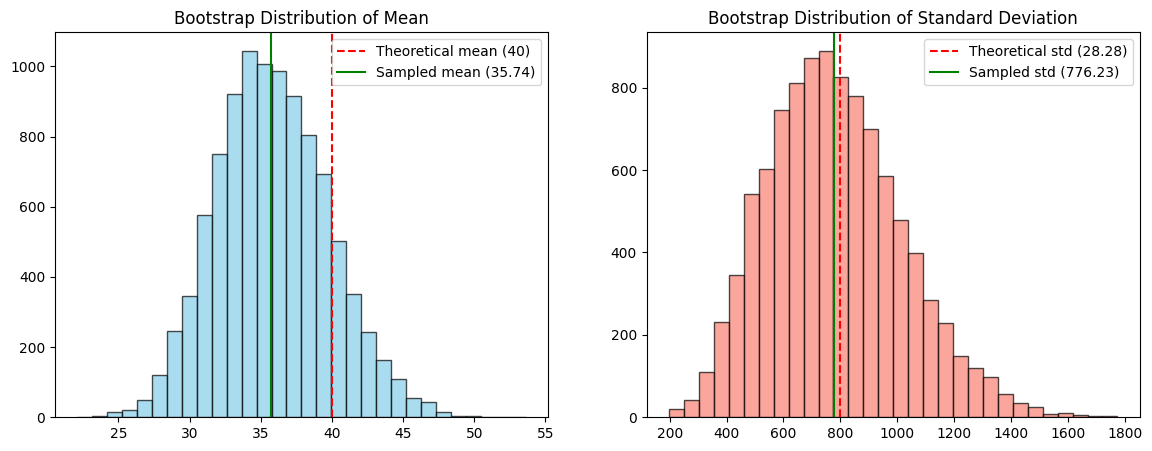

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mean
ax1.hist(boot_means, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(40, color='red', linestyle='--', label=f'Theoretical mean ({40})')
ax1.axvline(mean_gamma, color='green', linestyle='-', label=f'Sampled mean ({mean_gamma:.2f})')
ax1.set_title('Bootstrap Distribution of Mean')
ax1.legend()

# Std
ax2.hist(boot_vars, bins=30, color='salmon', edgecolor='black', alpha=0.7)
ax2.axvline(800, color='red', linestyle='--', label=f'Theoretical var ({800})')
ax2.axvline(var_gamma, color='green', linestyle='-', label=f'Sampled std ({var_gamma:.2f})')
ax2.set_title('Bootstrap Distribution of Standard Deviation')
ax2.legend()

plt.show()

### d)
Now you might have seen that there is certain gap between theoretical statistics and the ones we obtain with these estimations. This needs to happen since we are using small samples for doing our analysis. However, the interesting point of this bootstrap sampling method is that it allows us to create confidence intervals where our real parameter is included.

In the same way, we can use bootstrap to estimate not only the statistics like the mean, median or variance; but also the **parameters that describe the distribution**.

Since we have that:

$$E[X] = k\cdot \theta$$
$$Var[X] = k\cdot \theta^2$$

We can estimate:

$$ \hat{k} = \frac{\bar{X}^2}{\sigma^2}$$
$$\hat{\theta} = \frac{\sigma^2}{\bar{X}}$$

Estimate these two parameters with non-parametric bootstrap and plot histograms of the samples generated for both parameters.

In [53]:
import numpy as np
np.random.seed(1789)

boot_shapes = []
boot_thetas = []
for _ in range(20000):
    resample = np.random.choice(gamma_s, size=len(gamma_s), replace=True)
    k = (np.mean(resample) ** 2) / np.var(resample)
    theta = np.var(resample) / np.mean(resample)
    boot_shapes.append(k)
    boot_thetas.append(theta)

print("95% CI for shape:", np.percentile(boot_shapes, [2.5, 97.5]))
print("95% CI for scale:", np.percentile(boot_thetas, [2.5, 97.5]))

95% CI for shape: [1.16641009 2.78365617]
95% CI for scale: [11.74605031 31.41137151]


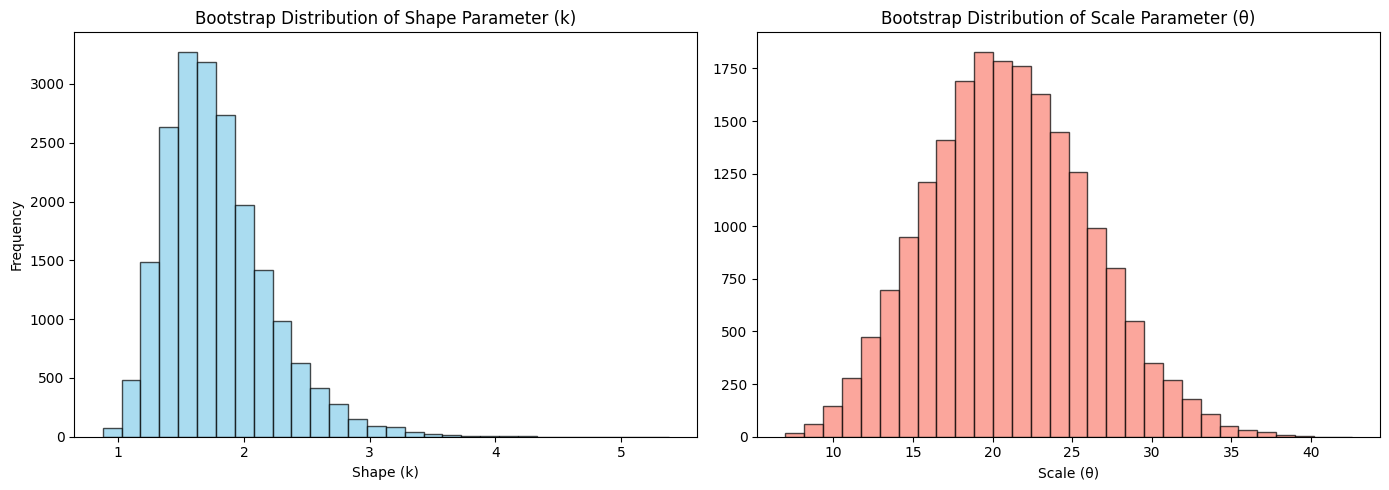

In [54]:
from matplotlib import pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(boot_shapes, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Bootstrap Distribution of Shape Parameter (k)')
ax1.set_xlabel('Shape (k)')
ax1.set_ylabel('Frequency')

ax2.hist(boot_thetas, bins=30, color='salmon', edgecolor='black', alpha=0.7)
ax2.set_title('Bootstrap Distribution of Scale Parameter (θ)')
ax2.set_xlabel('Scale (θ)')

plt.tight_layout()
plt.show()

### e)
You might have seen that in the distribution of any of the parameters has a long tail. This bootstrap methods can also be used to estimate the **Bias** of our estimates.
$$\text{Bias}(\hat{\theta}) = E[\hat{\theta}] - \theta$$
$$\hat{\text{Bias}} (\hat{\theta}) = \bar{\theta^*} - \hat{\theta}$$

To estimate this Bias what we can follow these steps:

- Obtain the point estimate of the parameter from the small sample -> $\hat{\theta}$

- Generate a bootstrap sample of this same parameter -> $\theta^*$

- Calculate the mean of the bootstrap sample -> $\bar{\theta^*}$

- Calculate $\bar{\theta^*}$ - $\hat{\theta}$


Do this for both the shape and the scale. 

In [55]:
import numpy as np
np.random.seed(1789)

# Obtain point estimates
k_hat = (np.mean(gamma_s) ** 2) / np.var(gamma_s)
theta_hat = np.var(gamma_s) / np.mean(gamma_s)

print("Point Estimate of Shape (k):", k_hat)
print("Point Estimate of Scale (θ):", theta_hat)

# Obtain bootstrap samples
boot_shapes = []
boot_thetas = []
for _ in range(20000):
    resample = np.random.choice(gamma_s, size=len(gamma_s), replace=True)
    k = (np.mean(resample) ** 2) / np.var(resample)
    theta = np.var(resample) / np.mean(resample)
    boot_shapes.append(k)
    boot_thetas.append(theta)

# Calculate means of bootstrap samples
mean_k = np.mean(boot_shapes)
mean_theta = np.mean(boot_thetas)

print("Bootstrap Mean of Shape (k):", mean_k)
print("Bootstrap Mean of Scale (θ):", mean_theta)

# Calculate differece
bias_k = mean_k - k_hat
bias_theta = mean_theta - theta_hat

print("Bias of Shape (k):", bias_k)
print("Bias of Scale (θ):", bias_theta)

Point Estimate of Shape (k): 1.6454151738742326
Point Estimate of Scale (θ): 21.719886189052467
Bootstrap Mean of Shape (k): 1.786899656967651
Bootstrap Mean of Scale (θ): 21.027067048704414
Bias of Shape (k): 0.14148448309341832
Bias of Scale (θ): -0.6928191403480533


## Exercise 3

This is our first step into the world of Hypothesis Testing. This is one of the most critical tools in statistics, widely used across countless scientific fields to draw objective, data-driven conclusions.

First question: **What is a Hypothesis Test?**

Conceptually, it can be a bit counter-intuitive. A hypothesis test measures how **"strange"** or unlikely our initial assumption (*The Null Hypothesis*, $H_0$) is compared to what the actual data is telling us.

The best way to understand this is by applying it. We will use the famous penguins dataset (available via the seaborn library), which contains biological measurements of various penguin species. It is already loaded.

In [ ]:
import seaborn as sns

penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


For this exercise, we will focus on two specific variables:

- island

- flipper_length_mm

Let’s imagine that, based on prior intuition, we check the average flipper length and we comprobe that it is close to $200$, therefore, we might assume that the average length for the penguins of Torgersen Island is also $200$ mm. So we propose the following:

- The Null Hypothesis ($H_0$): Penguins on Torgersen Island have an average flipper length of 200 mm -> $\mu=200$
- The Alternative Hypothesis ($H_A$): The average flipper length is different than 200 mm -> $\mu\neq200$


Our goal is to evaluate whether this claim holds up or if the data provides enough evidence to reject it.

### a)
First task: Filter the dataset to include only the observations for penguins living on Torgersen Island and calculate:

- The mean and variance of flipper length for the whole dataset
- The mean and variance of flipper length for the penguins living on Torgersen

In [57]:
import numpy as np
torgersen = penguins[penguins['island'] == 'Torgersen']["flipper_length_mm"]

print("All penguins flipper lengths:")
print("Mean:", np.mean(penguins["flipper_length_mm"]))
print("Variance:", np.var(penguins["flipper_length_mm"]))

print("Torgersen flipper lengths:")
print("Mean:", np.mean(torgersen))
print("Variance:", np.var(torgersen))

All penguins flipper lengths:
Mean: 200.96696696696696
Variance: 195.8517616715815
Torgersen flipper lengths:
Mean: 191.53191489361703
Variance: 37.866002716161155


We have seen that the average for the sample is not the same of the whole population but relatively close, it is actually $191.5$. Might we think this difference is due just to random effect? Is this difference big enough so we refuse or prior idea? It does not look a big difference.

**Let's continue the test!**

Now that we have selected the data we can compare it with our initial idea. The first approach we will try is the permutation test (for only one population).

**We start assuming the null hypothesis to be True**. Since, we assume $\mu_0=200$, we might agree that if we rest $200$ to the sample, the result will be centered in $0$.

$$E[X - a] = E[X] - a$$

Also, if our hypothesis is true, in our new $0$-centered sample, half of the values might be above 0 and other half below.

Now imagine this situation: if we *randomly* multiply each component of this sample by $1$ or $-1$, it would force that half of the samples would be above $0$ and below $0$. Therefore, the mean would be forced to be $\mu=0$, even if the original sample did not have that average.

Just to illustrate this situation, let's simulate it to understand what is happening:

### b)
Simulate a gaussian sample of size $1000000$ , with mean $10$ and variance $5$. Of course, this sample is not cenetered in $0$. So now multiply each of the observations randomly by $1$ or $-1$. Once you have done this, compute the mean and plot a histogram of this result. Is it close to $0$? What do you see in the histogram?

Mean of modified sample: -0.014280070087669964


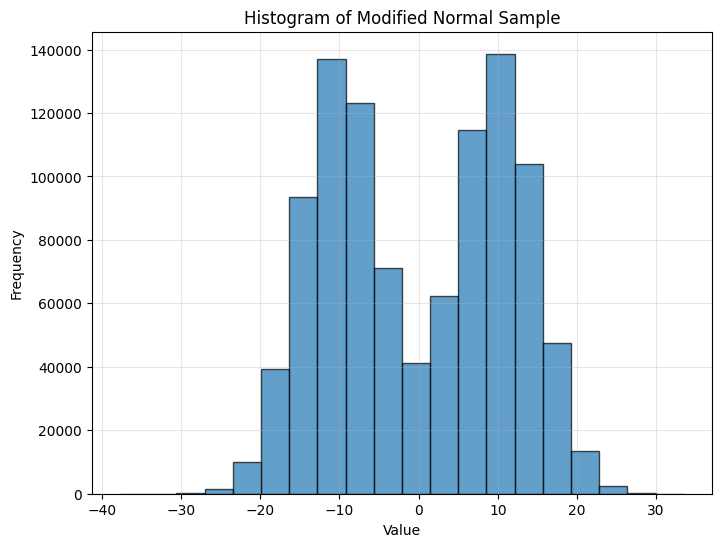

In [58]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2026)

sample = np.random.normal(10, 5, 1000000)
signs = np.random.choice([1, -1], size=1000000)
modified_sample = sample * signs
print(f"Mean of modified sample: {np.mean(modified_sample)}")

plt.figure(figsize=(8, 6))
plt.hist(modified_sample, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Modified Normal Sample')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

<span style="color:red">The average is very close to 0, nevertheless, in the histogram we can recognise that half of the samples are centered in 10 and other half are centered in -10</span>

We could see that if we multiply randomly by 1 or -1, the mean is forced to be at 0. We can simulate this many times, with random multiplications by 1 or -1, and have many "synthetic" populations, and we can calculate the mean of each of them. With all these sinthetic populations we can do comparisons with the original sample from the data.

Specifically, what we want to see is if the difference between the observed mean (the mean of the population $\bar{x}$) and the assumed mean ($\mu_0$) is strange. How do we measure if it is "strange". We can see the proportion of the averages of the synthetic samples that are greater than this observed difference. This is our **p-value**. So let's go step by step.

### c)
1. Calculate the *observed difference*: The difference between the observed mean and the assumed mean ($\bar{x} - \mu_0$)
2. As we assume the null hypothesis to be true, rest $\mu_0$ to the whole sample.
3. Create $100000$ synthetic samples by randomly multiplying the observations by $1$ or $-1$ and store the mean of each of the populations.
4. Calculate the proportion of the simulated means that are greater (**in absolute terms**) than the observed mean (**also in absolute terms**), you can call this your *p-value*
5. Show the value of the observed difference and the p-value. Can we refuse the Null Hypothesis?

* Note: We talk about *absolute terms* because in the alternative hypothesis we are evaluating both cases where $\mu_0>200$ or $\mu_0<200$ 

In [ ]:
import numpy as np
np.random.seed(2026)

mu_0 = 200
observed_mean = np.mean(torgersen)
observed_diff = observed_mean - mu_0
centered_data = torgersen - mu_0 # We set the mean to 0, assuming the null hypothesis is true

n_iterations = 100000
permuted_means = []

for i in range(n_iterations):
    random_signs = np.random.choice([1, -1], size=len(centered_data))
    permuted_means.append(np.mean(centered_data * random_signs))

p_value = np.mean(np.abs(permuted_means) >= np.abs(observed_diff))

print(f"Observed mean: {observed_mean} mm")
print(f"Observed difference with H0: {observed_diff} mm")
print(f"p-value: {p_value}")

Observed mean: 191.53191489361703 mm
Observed difference with H0: -8.468085106382972 mm
p-value: 0.0


### d)
Show in a histogram the simulated means and add vertical lines with the values of the observed mean (both negative and possitive).

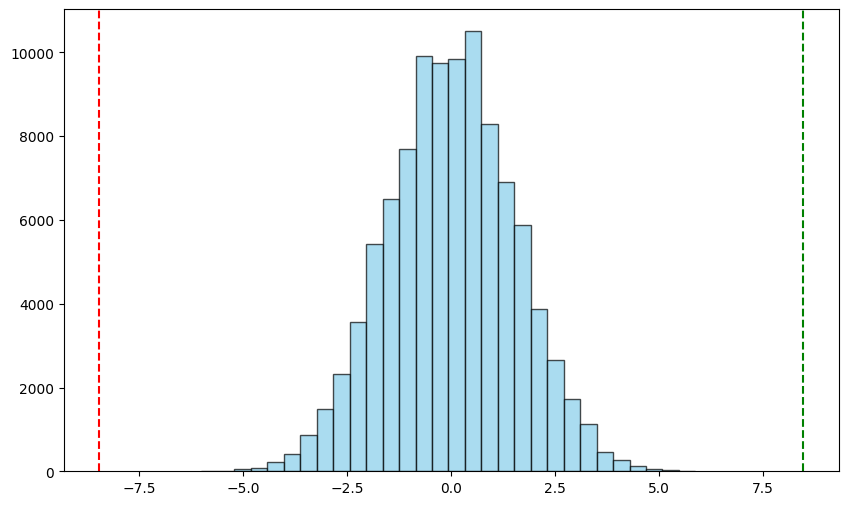

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(permuted_means, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(observed_diff, color='red', linestyle='--', label=f'Observed Diff ({observed_diff:.2f})')
plt.axvline(-observed_diff, color='green', linestyle='--', label=f'Negative Observed Diff ({-observed_diff:.2f})')
plt.show()

### e)

Now we are going to try a different method. We will do a **t-test** to compare the same hypothesis. And we will start going through all steps for finally compare the result with the default function.

What you need first to do is to calculate, from the selected sample:
- $\bar{x}$: The average of the sample
- $s$: The standar deviation
- $n$: The number of data points

Calculate all these three things.
And then, calculate the Standar Error ($SE$) which is calculated as $SE=\frac{s}{\sqrt{n}}$

In [61]:
import numpy as np

x_bar = np.mean(torgersen)
s = np.std(torgersen, ddof=1)
n = len(torgersen)

se = s / np.sqrt(n)

### f)

The standar error we just calculated measures measures how much we expect the mean to vary purely by chance.
However, we can still not say if the result we obtained is *strange* enough. What we will use now is the *t-statistic*. We calculate it in this way:

$$t = \frac{\bar{x} - \mu}{s}$$

So now calculate this value.

In [62]:
mu_0=200
t_stat = (x_bar - mu_0) / se

### g)
We are almost there! But we need one more thing!
We have now this *t-statistic*, this term tells us how far off what we observed (the penguin data) was from what we expected, but this alone term does not say anything, we need to do one last step.

Statistical theory tells us that our t-statistic follows a specific distribution known as the Student's t-distribution with $n - 1$ degrees of freedom ($df$):$$t \sim t(n-1)$$

Before looking at our results, we must establish a "rule of thumb" to decide whether to reject our assumption. This threshold is called the significance level ($\alpha$).
For this study, we set $\alpha = 0.05$.

The p-value is the probability of obtaining a $t$-statistic as extreme as the one we calculated, assuming $H_0$ is true.
Since we are testing whether the mean is different from 200 (regardless of whether it is higher or lower), we perform a two-tailed test. This means that we want to find the probability: $P(T < -|t_{obs}|)$ or $P(T > |t_{obs}|)$, but ince this distribution is simmetrict, just calculating $2\cdot P(T < -|t_{obs}|)$ will reach us to the same result.

- If $p\text{-value} < 0.05$: The probability of our hypothesis ($H_0$) being consistent with the data is too low. We reject the null hypothesis.

- If $p\text{-value} \geq 0.05$: We do not have enough evidence to rule it out. We fail to reject the null hypothesis.


Based on the data from Torgersen Island:
- Is our calculated p-value smaller than 0.05?
- Does our $t$-statistic fall beyond the critical quantiles for $\alpha = 0.05$?
- Do we have enough evidence to claim the average flipper length is NOT 200 mm?

$\color{red}{\text{You can use the function }\texttt{scipy.stats.t.cdf}}$

In [63]:
import scipy

p_value_manual = 2 * scipy.stats.t.cdf(-np.abs(t_stat), n-1)
print("T-statistic:", t_stat, "\nP-value:", p_value_manual)
if p_value_manual < 0.05:
    print("Refuse null hypothesis")
else:
    print("Cannot refuse null hypothesis")

T-statistic: -9.333389693129138 
P-value: 3.483646939335457e-12
Refuse null hypothesis


### h)
Finally, now that we have done the whole procedure and know how to do a test-hypothesis with the t-test we will see that we can actually do the same with just one function, automatically.

Use the function `scipy.stats.ttest_1samp` to do the same test we just did. Compare the result with the whole previous procedure. Do we arrive to the same conclusion?

In [64]:
import scipy
t_scipy, p_scipy = scipy.stats.ttest_1samp(torgersen, mu_0)
print("T-statistic:", t_scipy, "\nP-value:", p_scipy)
if p_scipy < 0.05:
    print("Refuse null hypothesis")
else:
    print("Cannot refuse null hypothesis")

T-statistic: -9.333389693129138 
P-value: 3.483646939335457e-12
Refuse null hypothesis


### i)
Now that we have a better idea of what is hypothesis test let's try something different with this same dataset!
What we are going to compare now is whether the male penguin’s beak is **larger** than the female’s. 

- $H_0: \mu_{males} = \mu_{females}$
- $H_A: \mu_{males} > \mu_{females}$

The first task is to prepare two variables, one with the `bill_length_mm` of the observations where `sex = Male` and another where `sex = Female`. Show in a boxplot the distribution of the 2 populations.

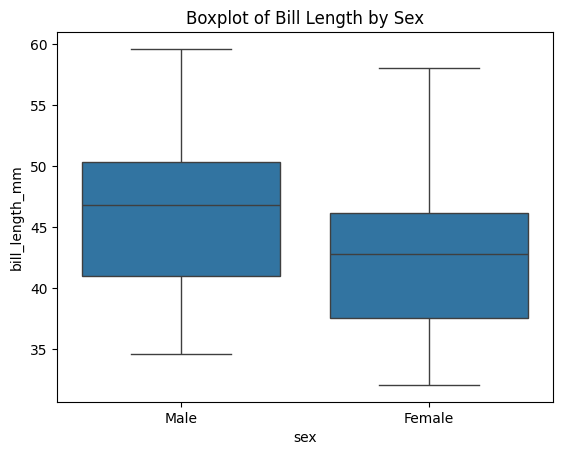

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

male_bill = penguins[penguins['sex'] == 'Male']['bill_length_mm']
female_bill = penguins[penguins['sex'] == 'Female']['bill_length_mm']

sns.boxplot(data=penguins, x='sex', y='bill_length_mm')
plt.title('Boxplot of Bill Length by Sex')
plt.show()

### j)
The exercise will consist on a comparison between **Two independent samples**. We will proceed on this way: Calculate for both groups:
- Mean ($\bar{x}_1, \bar{x}_2$)
- Variances ($s_1^2, s_2^2$)
- Sample size ($n_1, n_2$)

With all of this we can also calculate the *pooled variance* ($s_p^2$) like this:

$$s_p^2 = \frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}$$

Compute all these terms.

In [66]:
import numpy as np

n1, n2 = len(male_bill), len(female_bill)
m1, m2 = np.mean(male_bill), np.mean(female_bill)
v1, v2 = np.var(male_bill, ddof=1), np.var(female_bill, ddof=1)

pooled_var = ((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2)

### k)
The next step is to calculate the *estandar error of the difference* ($SE_{diff}$):
 $$SE_{diff} = \sqrt{s_p^2 \left( \frac{1}{n_1} + \frac{1}{n_2} \right)}$$
 This term measures how significant these changes tend to be. Compute it.

In [67]:
import numpy as np
se_diff = np.sqrt(pooled_var * (1/n1 + 1/n2))

### l)
And with all the terms we already calculated we can compute the *t-statistic*, and therefore, the *p-value*.
For this case, the *t-statistic* is defined as:
$$t = \frac{\bar{x}_1 - \bar{x}_2}{SE_{diff}}$$
And this term is distributed as:
$$t \sim t(n_1 + n_2 - 2)$$
So we can finally calculte the *p-value*!

You should take into account that now we are comparing only if the male's penguis beak is larger than female's, is **not** a two-tailed test, we want to see only the case $P(T > |t_{obs}|)$. Setting a significance level $\alpha = 0.05$. Can we refuse the Null hypothesis?

In [68]:
import scipy

t_manual = (m1 - m2) / se_diff
p_manual = 1 - scipy.stats.t.cdf(np.abs(t_manual), n1 + n2 - 2)

print("T-statistic:", t_manual, "\nP-value:", p_manual)
if p_manual < 0.05:
    print("Refuse null hypothesis")
else:
    print("Cannot refuse null hypothesis")

T-statistic: 6.667027633163075 
P-value: 5.471278985424988e-11
Refuse null hypothesis


### m)
And, as the last step, use the `scipy.stats.ttest_ind` to do everything we have done until now automatically. Do you appreciate any difference? Do we have the same result? What is the result now? Should we refuse the Null Hypothesis?

In [69]:
import scipy

t_stat_sci, p_value_sci = scipy.stats.ttest_ind(male_bill, female_bill, alternative='greater')
print("T-statistic:", t_stat_sci, "\nP-value:", p_value_sci)
if p_value_sci < 0.05:
    print("Refuse null hypothesis")
else:
    print("Cannot refuse null hypothesis")

T-statistic: 6.667027633163075 
P-value: 5.4712776935996045e-11
Refuse null hypothesis
